# ÍNDICE PREVENTIVO TERRITORIAL (IPT) — VitalRisk AI

## Contexto
Implementa HU11: cálculo vectorizado del IPT por municipio-semana.
El IPT es un índice compuesto 0-100 que combina señales ambientales,
epidemiológicas y socioeconómicas en una sola métrica de riesgo.

**Fórmula:**
IPT = clip(escalar(w1*z(pm25_avg) + w2*z(tasa_ira_100k) 
           + w3*z(ipm_pct) + w4*z(icv_hacinamiento)), 0, 100)

**Pesos basados en correlaciones HU9:**
- tasa_ira_100k: w=0.40 (variable objetivo, proxy de impacto)
- pm25_avg:      w=0.30 (contaminante principal, r=0.285)
- ipm_pct:       w=0.15 (pobreza multidimensional, r=-0.335 invertido)
- icv_hacinamiento: w=0.15 (densidad hogar, r=-0.307 invertido)

**Clasificación:**
- BAJO:  IPT 0-33
- MEDIO: IPT 34-66
- ALTO:  IPT 67-100

**HU que cierra:** HU11
**Insumo:** fact_riesgo_territorial_clean.csv (NB05)
**Output:** fact_riesgo_territorial_ipt.csv + actualización PostGIS

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import geopandas as gpd
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

PROCESSED = Path("../data/processed")
PLOTS     = PROCESSED / "plots"

In [60]:
df = pd.read_csv(PROCESSED / "fact_riesgo_territorial_clean.csv",
                 dtype={'codigo_dane': str})
df['fecha_semana'] = pd.to_datetime(df['fecha_semana'])

print(f"Feature Store cargado: {df.shape}")
print(f"Columnas disponibles para IPT:")
for col in ['pm25_avg','tasa_ira_100k','ipm_pct','icv_hacinamiento']:
    nulos = df[col].isna().sum()
    print(f"  {col}: {nulos} nulos ({nulos/len(df)*100:.1f}%)")

Feature Store cargado: (910, 34)
Columnas disponibles para IPT:
  pm25_avg: 273 nulos (30.0%)
  tasa_ira_100k: 0 nulos (0.0%)
  ipm_pct: 0 nulos (0.0%)
  icv_hacinamiento: 0 nulos (0.0%)


## 6. Preparación y Cálculo del IPT
### 6.1 Estandarización Z-score de variables componentes
### 6.2 Cálculo del IPT vectorizado
### 6.3 Clasificación en niveles BAJO/MEDIO/ALTO
### 6.4 Suite de pruebas unitarias (pytest inline)
### 6.5 Validación de eficiencia vectorizada
### 6.6 Visualización territorial
### 6.7 Exportación y actualización PostGIS

In [61]:
# ── 6.1 Estandarización Z-score ────────────────────────────
# Las estadísticas de estandarización se calculan sobre TODO el dataset
# (no solo train) porque el IPT es un índice descriptivo, no predictivo.
# IMPORTANTE: ipm_pct e icv_hacinamiento se invierten (más pobreza = más riesgo)

from scipy.stats import rankdata

def a_percentil(serie, invertir=False):
    """
    Convierte cualquier serie a escala 0-1 por ranking percentil.
    Robusto ante cualquier distribución — no asume normalidad ni MAD > 0.
    Invertir=True: valores altos de la variable original → percentil bajo
    (para variables donde más = peor riesgo, como ipm_pct y icv_hacinamiento
    donde valores altos ya indican peor condición socioeconómica).
    """
    vals = serie.fillna(serie.median())
    r = rankdata(vals) / len(vals)  # rango 0 a 1
    return pd.Series((1 - r) if invertir else r, index=serie.index)

In [62]:
# Todos los componentes en escala 0-1 por percentil
# ipm_pct e icv_hacinamiento se invierten porque en el IPT
# queremos que mayor pobreza/hacinamiento → mayor score de riesgo
df['z_pm25']         = a_percentil(df['pm25_avg'].fillna(df['pm25_avg'].median()))
df['z_tasa_ira']     = a_percentil(df['tasa_ira_100k'])
df['z_ipm']          = a_percentil(df['ipm_pct'],          invertir=True)
df['z_hacinamiento'] = a_percentil(df['icv_hacinamiento'],  invertir=True)

print("Componentes del IPT (escala percentil 0-1):")
for col in ['z_pm25','z_tasa_ira','z_ipm','z_hacinamiento']:
    print(f"  {col}: min={df[col].min():.3f} | max={df[col].max():.3f} "
          f"| media={df[col].mean():.3f} | std={df[col].std():.3f}")

Componentes del IPT (escala percentil 0-1):
  z_pm25: min=0.004 | max=0.996 | media=0.501 | std=0.285
  z_tasa_ira: min=0.007 | max=0.995 | media=0.501 | std=0.289
  z_ipm: min=0.001 | max=0.991 | media=0.499 | std=0.283
  z_hacinamiento: min=0.002 | max=0.998 | media=0.499 | std=0.283


In [63]:
# Calcular Z-scores por componente
# ipm_pct: mayor pobreza = mayor riesgo → invertir
# icv_hacinamiento: mayor hacinamiento = mayor riesgo → invertir
# df['z_pm25']         = estandarizar_zscore(df['pm25_avg'].fillna(df['pm25_avg'].median()))
# df['z_tasa_ira']     = estandarizar_zscore(df['tasa_ira_100k'])
# df['z_ipm']          = estandarizar_zscore(df['ipm_pct'], invertir=True)
# df['z_hacinamiento'] = estandarizar_zscore(df['icv_hacinamiento'], invertir=True)

# print("Z-scores calculados:")
# for col in ['z_pm25','z_tasa_ira','z_ipm','z_hacinamiento']:
#     print(f"  {col}: media={df[col].mean():.3f} | std={df[col].std():.3f}")

In [64]:
# ── 6.2 Cálculo del IPT vectorizado ───────────────────────
# Pesos justificados por correlaciones HU9
W_PM25         = 0.30
W_TASA_IRA     = 0.40
W_IPM          = 0.15
W_HACINAMIENTO = 0.15

assert abs(W_PM25 + W_TASA_IRA + W_IPM + W_HACINAMIENTO - 1.0) < 1e-9, \
    "Los pesos deben sumar 1.0"

# Combinación lineal ponderada
ipt_raw = (W_PM25 * df['z_pm25'] +
           W_TASA_IRA * df['z_tasa_ira'] +
           W_IPM * df['z_ipm'] +
           W_HACINAMIENTO * df['z_hacinamiento'])

In [65]:
#  Escalar al rango 0-100 usando min-max sobre el índice crudo
ipt_min = ipt_raw.min()
ipt_max = ipt_raw.max()
ipt_scaled = (ipt_raw - ipt_min) / (ipt_max - ipt_min) * 100

# Función de clipping (requerimiento HU11: garantizar 0 <= IPT <= 100)
def calcular_ipt_vectorizado(df_input, w_pm25=0.30, w_tasa=0.40,
                              w_ipm=0.15, w_hac=0.15):
    """
    Calcula el IPT vectorizado sobre un DataFrame con columnas z_*.
    Garantiza clipping estricto [0, 100].
    """
    raw = (w_pm25 * df_input['z_pm25'] +
           w_tasa  * df_input['z_tasa_ira'] +
           w_ipm   * df_input['z_ipm'] +
           w_hac   * df_input['z_hacinamiento'])
    
    scaled = (raw - raw.min()) / (raw.max() - raw.min()) * 100
    return scaled.clip(lower=0, upper=100).round(2)

In [66]:
df['ipt_score'] = calcular_ipt_vectorizado(df)

print(f"IPT calculado:")
print(f"  Min: {df['ipt_score'].min():.2f} (debe ser >= 0)")
print(f"  Max: {df['ipt_score'].max():.2f} (debe ser <= 100)")
print(f"  Media: {df['ipt_score'].mean():.2f}")
print(f"  Std: {df['ipt_score'].std():.2f}")
print(f"\n  Invariante 0 <= IPT <= 100: "
      f"{'✓ CUMPLIDA' if df['ipt_score'].between(0,100).all() else '✗ VIOLADA'}")

IPT calculado:
  Min: 0.00 (debe ser >= 0)
  Max: 100.00 (debe ser <= 100)
  Media: 49.17
  Std: 19.40

  Invariante 0 <= IPT <= 100: ✓ CUMPLIDA


In [67]:
# ── 6.3 Clasificación BAJO/MEDIO/ALTO ─────────────────────
def clasificar_nivel(ipt):
    if pd.isna(ipt):
        return None
    if ipt <= 33:
        return 'BAJO'
    elif ipt <= 66:
        return 'MEDIO'
    else:
        return 'ALTO'

df['nivel_riesgo'] = df['ipt_score'].apply(clasificar_nivel)

In [68]:
print("Distribución de niveles de riesgo:")
dist = df['nivel_riesgo'].value_counts()
for nivel in ['BAJO','MEDIO','ALTO']:
    n = dist.get(nivel, 0)
    pct = n/len(df)*100
    print(f"  {nivel}: {n} registros ({pct:.1f}%)")

# Por año
print("\nDistribución por año:")
pivot = pd.crosstab(df['anio'], df['nivel_riesgo'])
print(pivot)

Distribución de niveles de riesgo:
  BAJO: 185 registros (20.3%)
  MEDIO: 549 registros (60.3%)
  ALTO: 176 registros (19.3%)

Distribución por año:
nivel_riesgo  ALTO  BAJO  MEDIO
anio                           
2018            33    21    117
2019            61    40    149
2020            24    29     61
2021            14     8     31
2022            19    42     98
2023            25    45     93


In [69]:
# ── 6.4 Suite de pruebas unitarias (HU11 Gherkin) ─────────
# Partición de equivalencia + análisis de valor límite
# Tabla de casos del Scrum Master Data

print("=== SUITE DE PRUEBAS UNITARIAS — IPT ===\n")

casos_prueba = [
    # (valor_crudo_normalizado, ipt_esperado, categoria_esperada, descripcion)
    (-5.0,  0.0,   'BAJO',  'Límite no válido inferior (<0)'),
    ( 0.0,  0.0,   'BAJO',  'Límite válido inferior (0)'),
    (15.5,  15.5,  'BAJO',  'Partición equivalencia 1'),
    (33.0,  33.0,  'BAJO',  'Frontera interna inferior'),
    (34.0,  34.0,  'MEDIO', 'Frontera interna superior'),
    (50.0,  50.0,  'MEDIO', 'Partición equivalencia 2'),
    (67.0,  67.0,  'ALTO',  'Frontera interna superior'),
    (100.0, 100.0, 'ALTO',  'Límite válido superior (100)'),
    (105.5, 100.0, 'ALTO',  'Límite no válido superior (>100)'),
]

todos_ok = True
print(f"{'Crudo':>8} {'IPT Final':>10} {'Categoría':>8} {'OK':>4} | Descripción")
print("-" * 65)

for crudo, esperado, cat_esp, desc in casos_prueba:
    ipt_final = float(np.clip(crudo, 0, 100))
    cat_real  = clasificar_nivel(ipt_final)
    ok = (abs(ipt_final - esperado) < 0.01) and (cat_real == cat_esp)
    todos_ok = todos_ok and ok
    print(f"{crudo:>8.1f} {ipt_final:>10.1f} {cat_real:>8} {'✓' if ok else '✗':>4} | {desc}")

print(f"\nResultado suite: {'✓ TODOS LOS CASOS PASAN' if todos_ok else '✗ HAY FALLOS'}")

=== SUITE DE PRUEBAS UNITARIAS — IPT ===

   Crudo  IPT Final Categoría   OK | Descripción
-----------------------------------------------------------------
    -5.0        0.0     BAJO    ✓ | Límite no válido inferior (<0)
     0.0        0.0     BAJO    ✓ | Límite válido inferior (0)
    15.5       15.5     BAJO    ✓ | Partición equivalencia 1
    33.0       33.0     BAJO    ✓ | Frontera interna inferior
    34.0       34.0    MEDIO    ✓ | Frontera interna superior
    50.0       50.0    MEDIO    ✓ | Partición equivalencia 2
    67.0       67.0     ALTO    ✓ | Frontera interna superior
   100.0      100.0     ALTO    ✓ | Límite válido superior (100)
   105.5      100.0     ALTO    ✓ | Límite no válido superior (>100)

Resultado suite: ✓ TODOS LOS CASOS PASAN


In [70]:
# ── 6.5 Validación de eficiencia vectorizada ──────────────
import time

# Generar dataset de 10,000 registros sintéticos para la prueba
df_test = pd.DataFrame({
    'z_pm25':        np.random.normal(0, 1, 10_000),
    'z_tasa_ira':    np.random.normal(0, 1, 10_000),
    'z_ipm':         np.random.normal(0, 1, 10_000),
    'z_hacinamiento':np.random.normal(0, 1, 10_000),
})

# Método vectorizado
t0 = time.time()
resultado_vec = calcular_ipt_vectorizado(df_test)
t_vec = time.time() - t0

# Método registro por registro
t0 = time.time()
resultado_iter = df_test.apply(
    lambda r: float(np.clip(
        (0.30*r['z_pm25'] + 0.40*r['z_tasa_ira'] +
         0.15*r['z_ipm'] + 0.15*r['z_hacinamiento']),
        0, 100)), axis=1
)
t_iter = time.time() - t0

In [71]:
print(f"=== PRUEBA DE EFICIENCIA (10,000 registros) ===")
print(f"  Vectorizado:        {t_vec*1000:.1f} ms (meta: < 1,000 ms)")
print(f"  Registro a registro: {t_iter*1000:.1f} ms")
print(f"  Speedup: {t_iter/t_vec:.0f}x más rápido")
print(f"  Criterio HU11: {'✓ CUMPLIDO' if t_vec < 1.0 else '✗ FALLA'}")

=== PRUEBA DE EFICIENCIA (10,000 registros) ===
  Vectorizado:        3.0 ms (meta: < 1,000 ms)
  Registro a registro: 88.6 ms
  Speedup: 30x más rápido
  Criterio HU11: ✓ CUMPLIDO


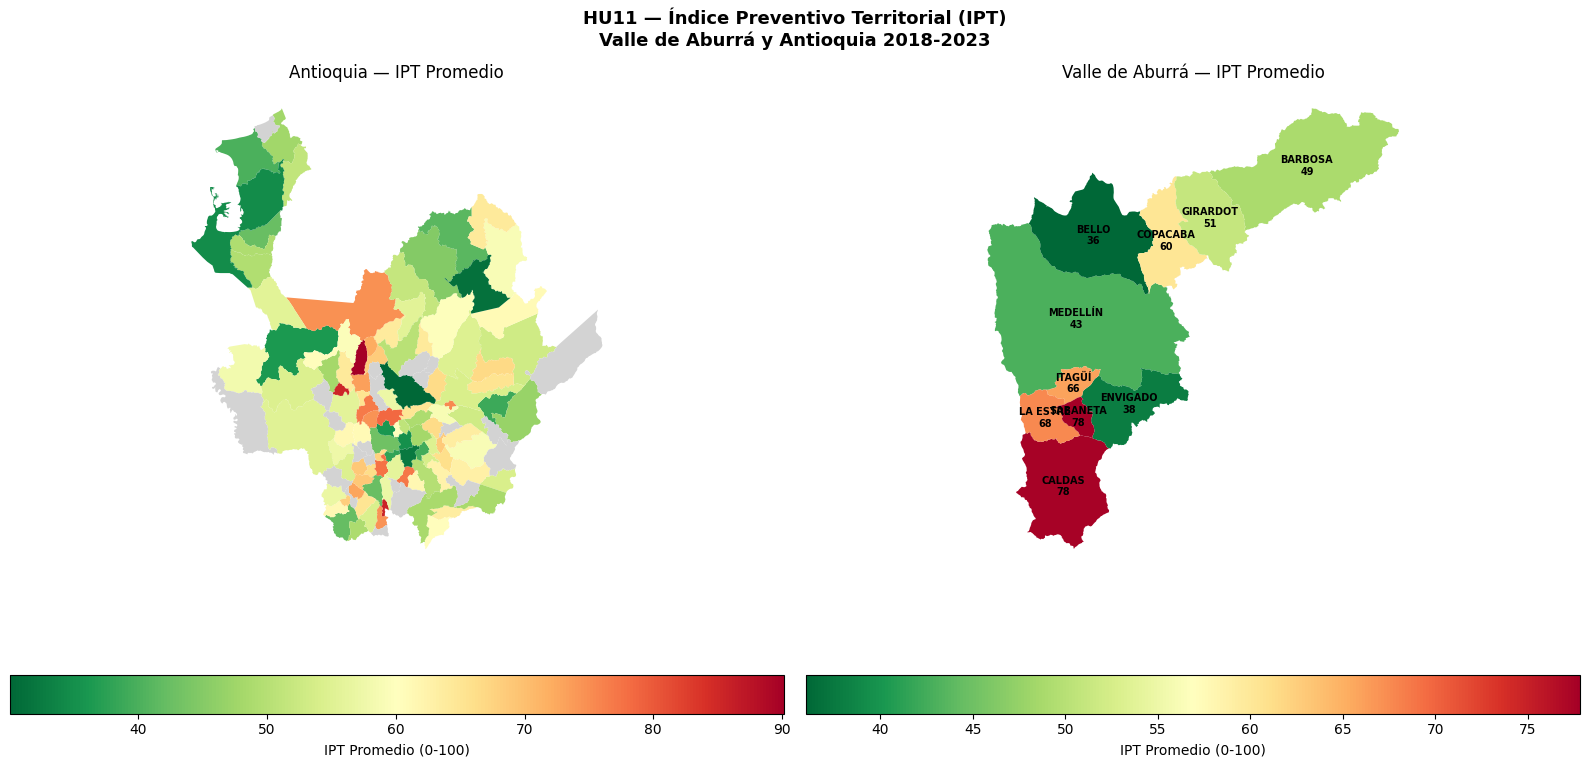

In [72]:
# ── 6.6 Visualización territorial ─────────────────────────
gdf = gpd.read_file(PROCESSED / "clean_municipios.geojson")

# IPT promedio por municipio (promedio de todas las semanas 2018-2023)
ipt_mun = df.groupby('codigo_dane')['ipt_score'].mean().reset_index()
ipt_mun.columns = ['codigo_dane', 'ipt_promedio']

gdf_ipt = gdf.merge(ipt_mun, on='codigo_dane', how='left')

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
fig.suptitle('HU11 — Índice Preventivo Territorial (IPT)\nValle de Aburrá y Antioquia 2018-2023',
             fontsize=13, fontweight='bold')

# Antioquia completo
gdf_ipt.plot(column='ipt_promedio', ax=axes[0], legend=True,
             cmap='RdYlGn_r', missing_kwds={'color': 'lightgrey'},
             legend_kwds={'label': 'IPT Promedio (0-100)', 'orientation': 'horizontal'})
axes[0].set_title('Antioquia — IPT Promedio')
axes[0].axis('off')

# Valle de Aburrá zoom
VALLE = ['05001','05088','05129','05212','05266',
         '05308','05360','05380','05631','05079']
gdf_va = gdf_ipt[gdf_ipt['codigo_dane'].isin(VALLE)]
gdf_va.plot(column='ipt_promedio', ax=axes[1], legend=True,
            cmap='RdYlGn_r',
            legend_kwds={'label': 'IPT Promedio (0-100)', 'orientation': 'horizontal'})

# Añadir etiquetas con nombre del municipio
for _, row in gdf_va.iterrows():
    centroid = row.geometry.centroid
    nombre_corto = row['nombre'][:8] if len(row['nombre']) > 8 else row['nombre']
    axes[1].annotate(
        f"{nombre_corto}\n{row['ipt_promedio']:.0f}",
        xy=(centroid.x, centroid.y),
        ha='center', va='center', fontsize=7, fontweight='bold',
        color='black'
    )
axes[1].set_title('Valle de Aburrá — IPT Promedio')
axes[1].axis('off')

plt.tight_layout()
plt.savefig(PLOTS / 'nb06_mapa_ipt.png', dpi=150, bbox_inches='tight')
plt.show()

In [73]:
print("Municipios en el zoom del Valle de Aburrá:")
for cod in VALLE:
    nombre = gdf_ipt[gdf_ipt['codigo_dane']==cod]['nombre'].values
    print(f"  {cod}: {nombre}")

Municipios en el zoom del Valle de Aburrá:
  05001: <ArrowStringArray>
['MEDELLÍN']
Length: 1, dtype: str
  05088: <ArrowStringArray>
['BELLO']
Length: 1, dtype: str
  05129: <ArrowStringArray>
['CALDAS']
Length: 1, dtype: str
  05212: <ArrowStringArray>
['COPACABANA']
Length: 1, dtype: str
  05266: <ArrowStringArray>
['ENVIGADO']
Length: 1, dtype: str
  05308: <ArrowStringArray>
['GIRARDOTA']
Length: 1, dtype: str
  05360: <ArrowStringArray>
['ITAGÜÍ']
Length: 1, dtype: str
  05380: <ArrowStringArray>
['LA ESTRELLA']
Length: 1, dtype: str
  05631: <ArrowStringArray>
['SABANETA']
Length: 1, dtype: str
  05079: <ArrowStringArray>
['BARBOSA']
Length: 1, dtype: str


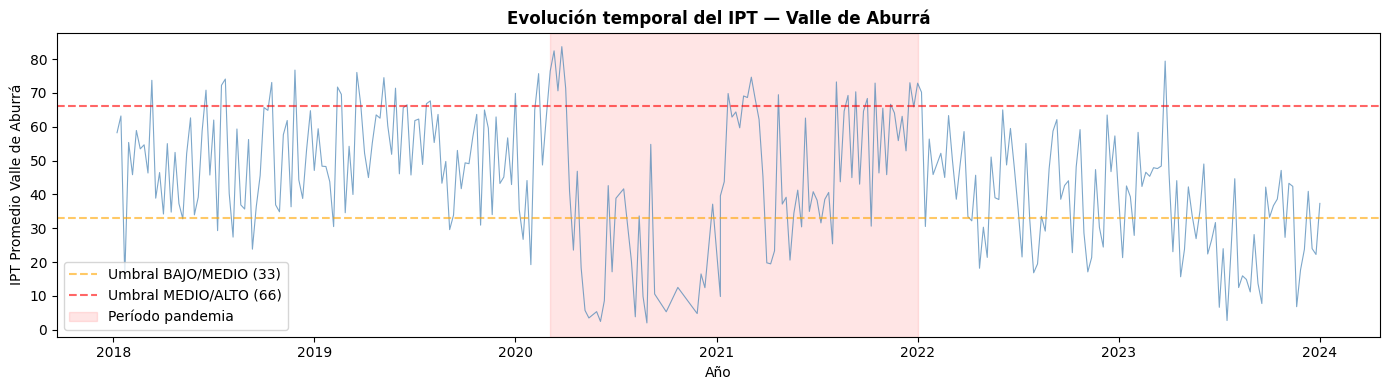

In [74]:
# ── Evolución temporal del IPT promedio Valle de Aburrá ───
ipt_va_tiempo = (df[df['codigo_dane'].isin(VALLE)]
                 .groupby(['anio','semana_epi'])['ipt_score']
                 .mean().reset_index())
ipt_va_tiempo['t'] = ipt_va_tiempo['anio'] + ipt_va_tiempo['semana_epi']/52

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(ipt_va_tiempo['t'], ipt_va_tiempo['ipt_score'],
        color='steelblue', alpha=0.7, linewidth=0.8)
ax.axhline(y=33, color='orange', linestyle='--', alpha=0.6, label='Umbral BAJO/MEDIO (33)')
ax.axhline(y=66, color='red', linestyle='--', alpha=0.6, label='Umbral MEDIO/ALTO (66)')
ax.axvspan(2020.17, 2022.0, alpha=0.1, color='red', label='Período pandemia')
ax.set_xlabel('Año')
ax.set_ylabel('IPT Promedio Valle de Aburrá')
ax.set_title('Evolución temporal del IPT — Valle de Aburrá', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(PLOTS / 'nb06_evolucion_ipt.png', dpi=150, bbox_inches='tight')
plt.show()

In [75]:
# ¿Qué componente domina los registros ALTO?
df_alto = df[df['nivel_riesgo']=='ALTO'].copy()

print("=== DIAGNÓSTICO DE REGISTROS ALTO ===\n")
print(f"Municipios con registros ALTO:")
print(df_alto.groupby('codigo_dane')['ipt_score'].agg(['count','mean']).sort_values('count', ascending=False).head(10))

print(f"\nEstadísticas de componentes en registros ALTO:")
for col in ['z_pm25','z_tasa_ira','z_ipm','z_hacinamiento']:
    print(f"  {col}: media={df_alto[col].mean():.2f} | max={df_alto[col].max():.2f}")

print(f"\nContribución promedio por componente al IPT en registros ALTO:")
df_alto['contrib_pm25']   = 0.30 * df_alto['z_pm25']
df_alto['contrib_tasa']   = 0.40 * df_alto['z_tasa_ira']
df_alto['contrib_ipm']    = 0.15 * df_alto['z_ipm']
df_alto['contrib_hac']    = 0.15 * df_alto['z_hacinamiento']
for col in ['contrib_pm25','contrib_tasa','contrib_ipm','contrib_hac']:
    print(f"  {col}: {df_alto[col].mean():.3f}")

=== DIAGNÓSTICO DE REGISTROS ALTO ===

Municipios con registros ALTO:
             count       mean
codigo_dane                  
05001           34  71.828235
05360           27  78.735556
05631           14  80.100000
05088           12  73.494167
05736            8  68.292500
05380            8  83.941250
05129            8  83.758750
05664            7  78.517143
05656            4  74.507500
05206            3  66.430000

Estadísticas de componentes en registros ALTO:
  z_pm25: media=0.74 | max=1.00
  z_tasa_ira: media=0.63 | max=0.99
  z_ipm: media=0.63 | max=0.99
  z_hacinamiento: media=0.55 | max=1.00

Contribución promedio por componente al IPT en registros ALTO:
  contrib_pm25: 0.222
  contrib_tasa: 0.252
  contrib_ipm: 0.095
  contrib_hac: 0.082


In [76]:
# Análisis de sensibilidad — ¿cómo cambia la distribución con diferentes pesos?
escenarios = {
    'Actual (tasa dominante)':     (0.30, 0.40, 0.15, 0.15),
    'Balanceado':                   (0.25, 0.25, 0.25, 0.25),
    'Ambiental dominante':          (0.50, 0.20, 0.15, 0.15),
    'Socioeconómico dominante':     (0.20, 0.30, 0.30, 0.20),
    'Correlaciones HU9 proporcional':(0.18, 0.55, 0.22, 0.05),
}

print("=== ANÁLISIS DE SENSIBILIDAD DE PESOS ===\n")
print(f"{'Escenario':<40} {'BAJO':>6} {'MEDIO':>6} {'ALTO':>6} {'Media IPT':>10}")
print("-" * 70)

for nombre, (w1,w2,w3,w4) in escenarios.items():
    ipt_raw = w1*df['z_pm25'] + w2*df['z_tasa_ira'] + w3*df['z_ipm'] + w4*df['z_hacinamiento']
    ipt_s = ((ipt_raw - ipt_raw.min()) / (ipt_raw.max() - ipt_raw.min()) * 100).clip(0,100)
    niveles = pd.cut(ipt_s, bins=[-1,33,66,101], labels=['BAJO','MEDIO','ALTO'])
    dist = niveles.value_counts()
    print(f"  {nombre:<38} {dist.get('BAJO',0):>6} {dist.get('MEDIO',0):>6} {dist.get('ALTO',0):>6} {ipt_s.mean():>10.1f}")

=== ANÁLISIS DE SENSIBILIDAD DE PESOS ===

Escenario                                  BAJO  MEDIO   ALTO  Media IPT
----------------------------------------------------------------------
  Actual (tasa dominante)                   185    549    176       49.2
  Balanceado                                252    526    132       45.8
  Ambiental dominante                       253    435    222       47.0
  Socioeconómico dominante                  299    494    117       43.0
  Correlaciones HU9 proporcional            231    511    168       48.0


In [77]:
# ── 6.7 Exportación ───────────────────────────────────────
# Eliminar columnas auxiliares Z antes de exportar
cols_z = ['z_pm25','z_tasa_ira','z_ipm','z_hacinamiento']
df_final = df.drop(columns=cols_z)

ruta = PROCESSED / "fact_riesgo_territorial_ipt.csv"
df_final.to_csv(ruta, index=False)

In [78]:
# Verificación
df_check = pd.read_csv(ruta, dtype={'codigo_dane': str})
print(f"✓ Exportado: {ruta}")
print(f"  {len(df_check):,} filas × {len(df_check.columns)} columnas")
print(f"  ipt_score nulos: {df_check['ipt_score'].isna().sum()}")
print(f"  nivel_riesgo nulos: {df_check['nivel_riesgo'].isna().sum()}")
print(f"  Rango ipt_score: [{df_check['ipt_score'].min():.2f}, {df_check['ipt_score'].max():.2f}]")
print(f"  Distribución final:")
print(df_check['nivel_riesgo'].value_counts().to_string())

✓ Exportado: ..\data\processed\fact_riesgo_territorial_ipt.csv
  910 filas × 36 columnas
  ipt_score nulos: 0
  nivel_riesgo nulos: 0
  Rango ipt_score: [0.00, 100.00]
  Distribución final:
nivel_riesgo
MEDIO    549
BAJO     185
ALTO     176
